In [1]:
import sys, os
from utils import * 


In [2]:
import joblib

DATASET_NAME, X_train, X_test, y_train, y_test = joblib.load("ULB_data.pkl")
y_test = y_test.values.ravel()

MODEL_NAME = "BGMM_Gibbs"
DE_LONG_RESULTS = "ULB_all_results.pkl"
METRICS = "ULB_metrics.pkl"


In [3]:
# ==================================================================
# ==================================================================
# ==================================================================
# ==================================================================
# ==================================================================
# ===================== 1. Fit BGMM with GIBBS =====================
# ==================================================================
# ==================================================================
# ==================================================================
# ==================================================================
# ==================================================================

In [4]:
# ===================== Fit BGMM with GIBBS =====================
bgmm_gibbs_train_scores, bgmm_gibbs_test_scores, bgmm = run_bgmm_gibbs(X_train, X_test)

In [10]:
# ===================== Store metrics =====================
bgmm_metrics = store_anomaly_metrics(y_true=y_test, scores=-bgmm_gibbs_test_scores, dataset_name=DATASET_NAME, model_name=MODEL_NAME)
display(bgmm_metrics)


,Model,Data,Precision,Precision_CI,Recall,Recall_CI,F1,F1_CI,ROC_AUC,ROC_AUC_CI,PR_AUC,PR_AUC_CI,Confusion_Matrix,Threshold
0,BGMM_Gibbs,creditcard,0.003159,0.001-0.005,0.091837,0.043-0.155,0.006108,0.003-0.011,0.609785,0.547-0.673,0.002941,0.002-0.005,"[[54024, 2840], [89, 9]]",-6.005933e+10


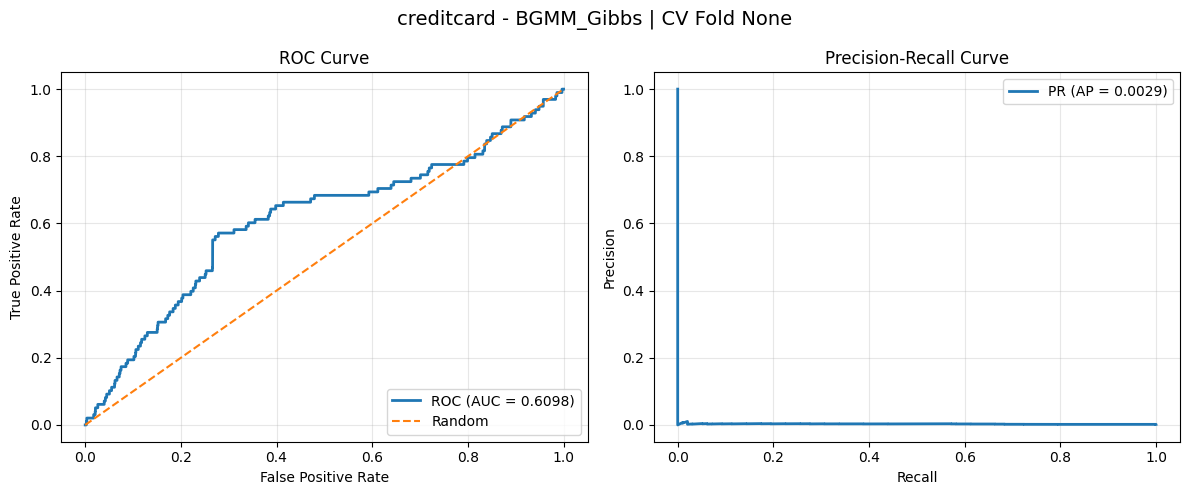

In [16]:
# ===================== Plot results =====================

plot_anomaly_roc_pr(y_true=y_test, dataset_name=DATASET_NAME, scores=-bgmm_gibbs_test_scores, model_name=MODEL_NAME)


In [7]:
# ===================== Fit on CV folds =====================

bgmm_cv_results = fit_cross_validate(X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, model_func=run_bgmm_gibbs, dataset_name=DATASET_NAME, model_name=MODEL_NAME, cv=CV_FOLDS, random_state=RANDOM_STATE)


In [8]:
# ===================== Store CV metrics =====================

bgmm_cv_metrics = pd.concat([r["test_metrics"] for r in bgmm_cv_results], ignore_index=True)
display(bgmm_cv_metrics)


,Model,Data,Precision,Precision_CI,Recall,Recall_CI,F1,F1_CI,ROC_AUC,ROC_AUC_CI,PR_AUC,PR_AUC_CI,Confusion_Matrix,Threshold
0,BGMM_Gibbs_Fold1,creditcard,0.001755,0.000-0.003,0.05102,0.011-0.096,0.003393,0.001-0.007,0.389583,0.327-0.453,0.001544,0.001-0.002,"[[54020, 2844], [93, 5]]",9.184382e+10
1,BGMM_Gibbs_Fold2,creditcard,0.001755,0.000-0.003,0.05102,0.011-0.096,0.003393,0.001-0.007,0.390881,0.328-0.454,0.001551,0.001-0.002,"[[54020, 2844], [93, 5]]",9.204379e+10
2,BGMM_Gibbs_Fold3,creditcard,0.001755,0.000-0.003,0.05102,0.011-0.096,0.003393,0.001-0.007,0.389933,0.327-0.453,0.001546,0.001-0.002,"[[54020, 2844], [93, 5]]",9.199011e+10
3,BGMM_Gibbs_Fold4,creditcard,0.001755,0.000-0.003,0.05102,0.011-0.096,0.003393,0.001-0.007,0.390888,0.328-0.454,0.001545,0.001-0.002,"[[54020, 2844], [93, 5]]",9.193877e+10
4,BGMM_Gibbs_Fold5,creditcard,0.001755,0.000-0.003,0.05102,0.011-0.096,0.003393,0.001-0.007,0.389644,0.326-0.453,0.001544,0.001-0.002,"[[54020, 2844], [93, 5]]",9.197359e+10


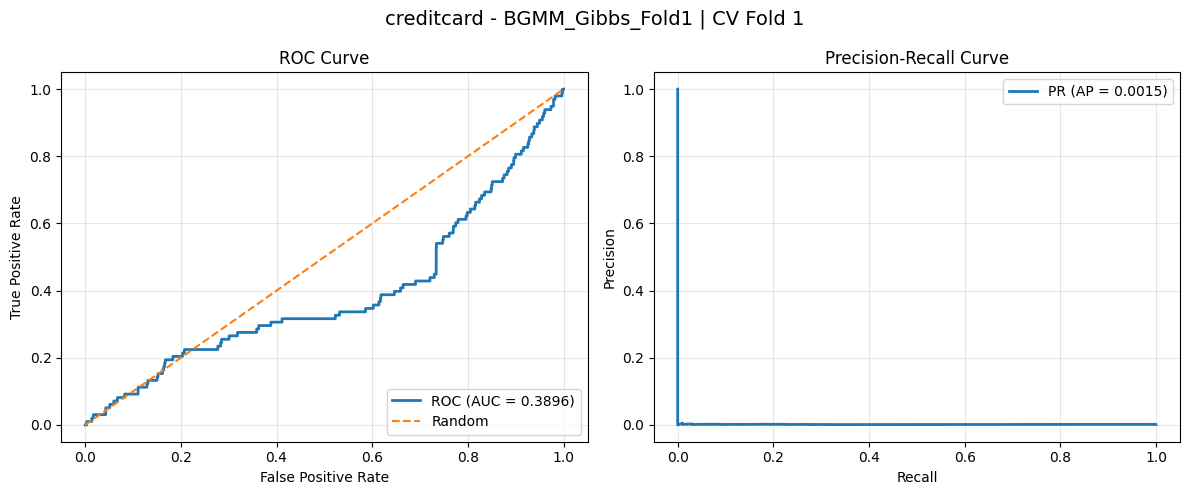

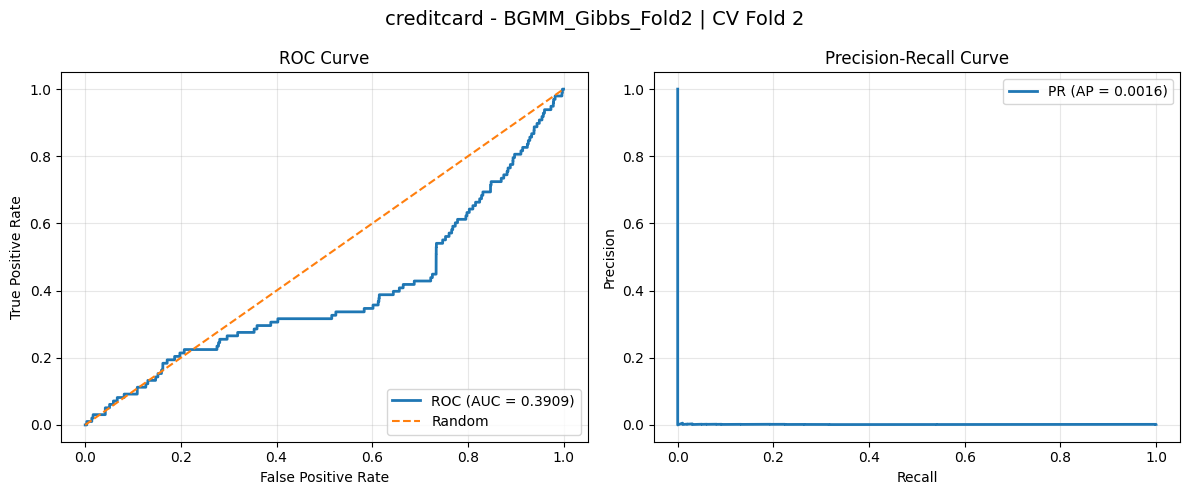

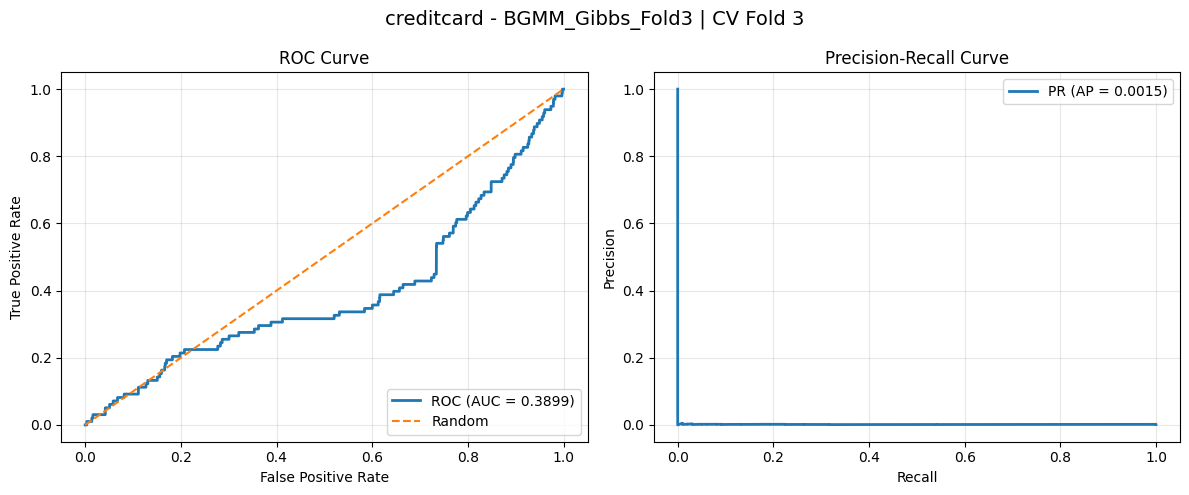

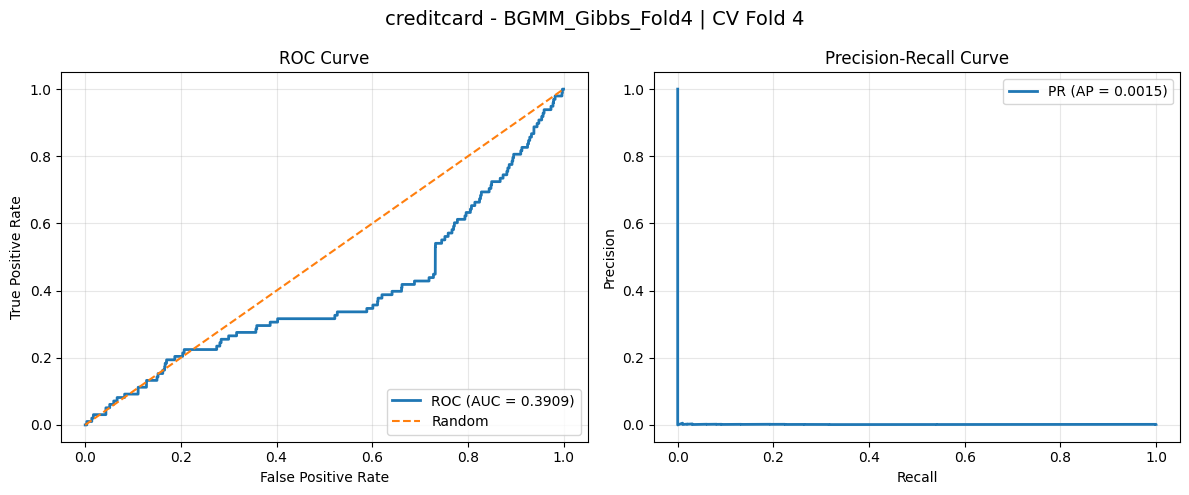

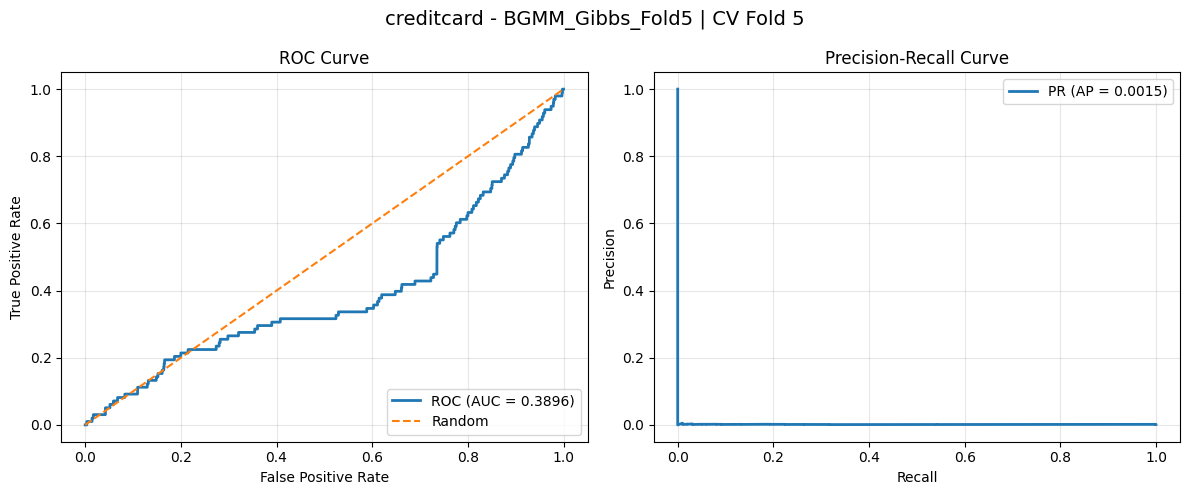

In [9]:
# ===================== Plot CV results =====================

for r in bgmm_cv_results:
    plot_anomaly_roc_pr(y_test, r["test_scores"], DATASET_NAME, f"{MODEL_NAME}_Fold{r['fold']}", r["fold"])


In [18]:
if os.path.exists(DE_LONG_RESULTS):
    results = joblib.load(DE_LONG_RESULTS)
else:
    results = {}

results[MODEL_NAME] = {
    "test_scores": -bgmm_gibbs_test_scores,
    "auc": roc_auc_score(y_test, -bgmm_gibbs_test_scores)
}

joblib.dump(results, DE_LONG_RESULTS)

['ULB_all_results.pkl']

In [12]:
if os.path.exists(METRICS):
    results = joblib.load(METRICS)
else:
    results = {}

results[MODEL_NAME] = {
    "metrics": bgmm_metrics,
    "cv_metrics": bgmm_cv_metrics
}

joblib.dump(results, METRICS)

['ULB_metrics.pkl']